In [1]:
from src.measure_ir import *
import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf
from src.real_time import RealtimeFxLMS

In [2]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
ad = AudioDevice(fs)

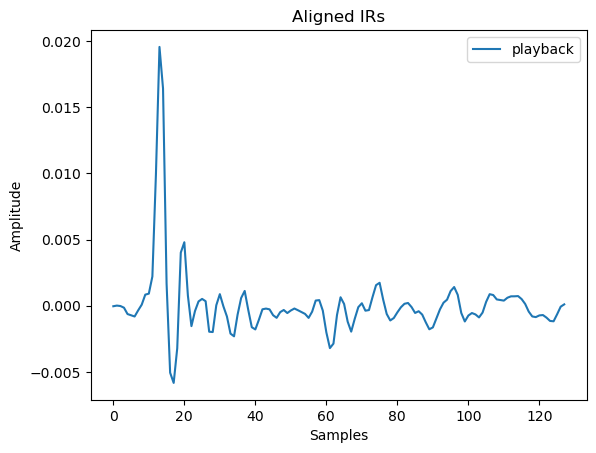

In [3]:
ir_len = 128
panel_to_err_cm = 9

error_ir, _ = measure_ir(ad)
panel_ir = align_ir_by_distance(error_ir, panel_to_err_cm, ir_len)

plt.plot(panel_ir, label="playback")

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Aligned IRs')
plt.legend()
plt.show()

In [4]:
arthur_repeated = np.tile(arthur, 50)

rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
    block_size=64,
)

Lag from cross-correlation: 4477
Delay from device: 4312


In [5]:
filter_orders = [256, 512, 1024, 2048, 4096]
block_sizes = [16, 64, 256, 1024]

In [6]:
for filt in filter_orders:
    for block in block_sizes:
        
        rt.reset(rt.system_lag, block_size=block, filter_order=filt)

        error, cancel, *_ = rt.run(
            source_gain=1.0,
            cancel_gain=.2,
            fx=True,
            nlms=True,
            clean_source=True,
            step_fn=1e-4,
            leak=1e-7,
            max_norm=1.0,
        )

        print('filter_order:', filt, 'block_size:', block, 'db_redux:', rt.db_reduction)


filter_order: 256 block_size: 16 db_redux: 1.6295367
filter_order: 256 block_size: 64 db_redux: 1.7131152
filter_order: 256 block_size: 256 db_redux: 1.5909678
filter_order: 256 block_size: 1024 db_redux: 2.1705346
filter_order: 512 block_size: 16 db_redux: 0.39427876
filter_order: 512 block_size: 64 db_redux: 0.9131091
filter_order: 512 block_size: 256 db_redux: 1.0768954
filter_order: 512 block_size: 1024 db_redux: 0.6518081
filter_order: 1024 block_size: 16 db_redux: -2.4778924
filter_order: 1024 block_size: 64 db_redux: -1.728114
filter_order: 1024 block_size: 256 db_redux: -2.5587204
filter_order: 1024 block_size: 1024 db_redux: -2.4048312
filter_order: 2048 block_size: 16 db_redux: -1.605234
filter_order: 2048 block_size: 64 db_redux: -2.2456267
filter_order: 2048 block_size: 256 db_redux: -2.2016532
filter_order: 2048 block_size: 1024 db_redux: -1.6398646
filter_order: 4096 block_size: 16 db_redux: -1.6941566
filter_order: 4096 block_size: 64 db_redux: -1.7312831
filter_order: 4

In [7]:
arthur_full, fs = sf.read('data/arthur_full.wav')
fs


48000

In [14]:
rt = RealtimeFxLMS(
    ad,
    source=arthur_full,
    ir=panel_ir,
    block_size=1024,
)

Lag from cross-correlation: 4468
Delay from device: 4312


In [15]:
filter_orders = [256, 512, 1024, 2048]

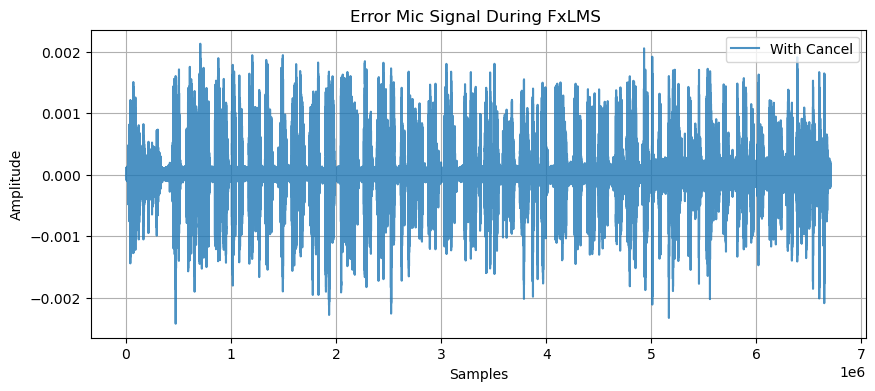

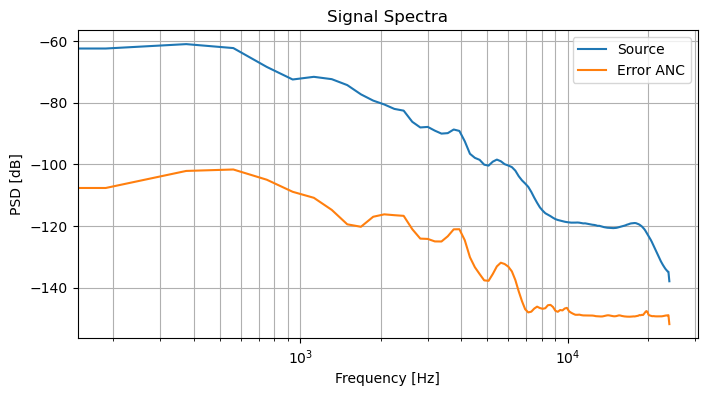

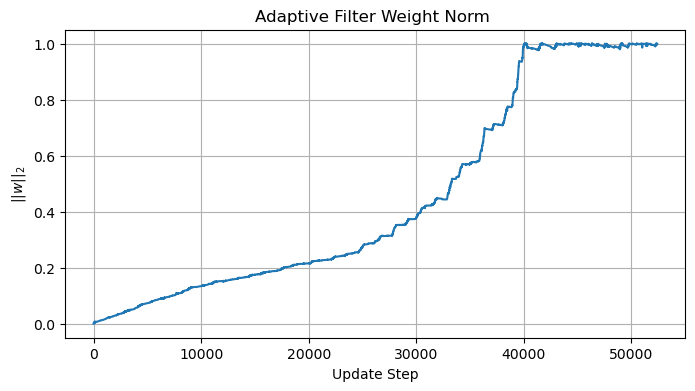

In [17]:
rt.reset(rt.system_lag, block_size=128, filter_order=1024)

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=.2,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=1e-4,
    leak=1e-7,
    max_norm=1.0,
)


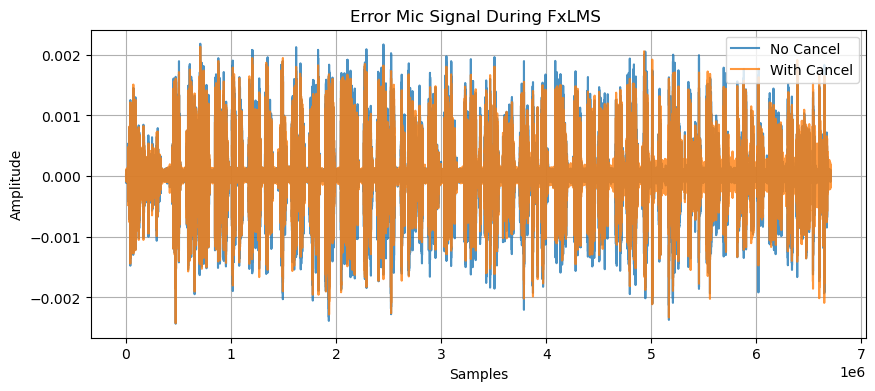

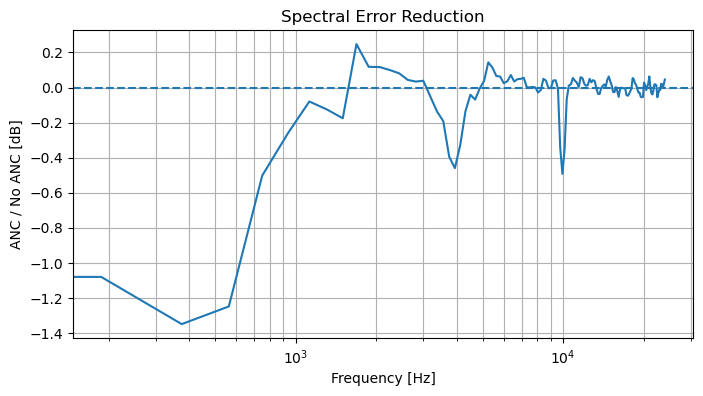

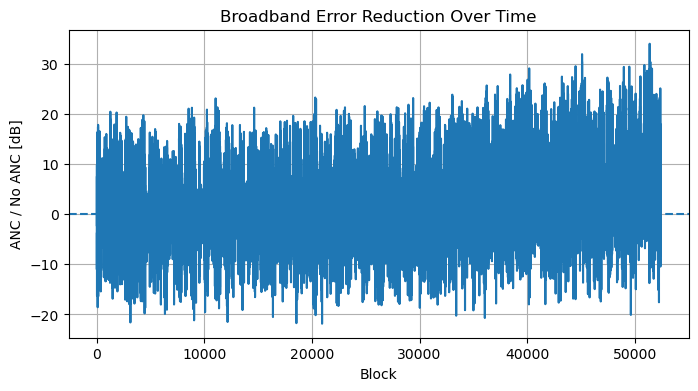

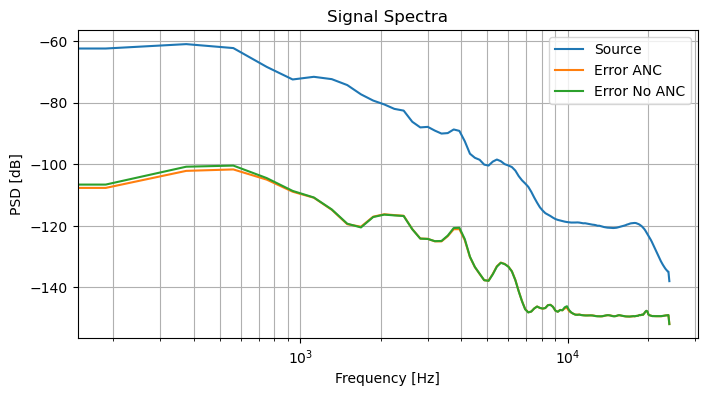

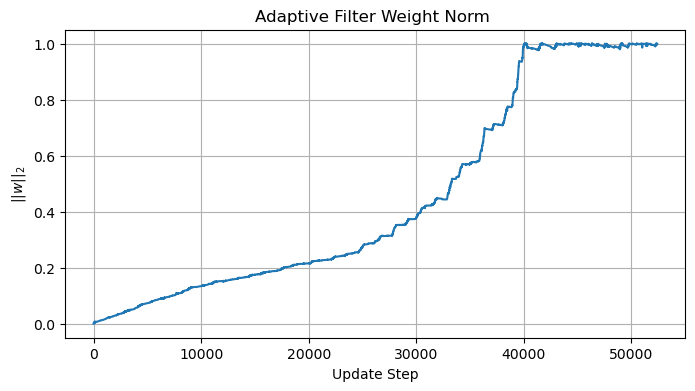

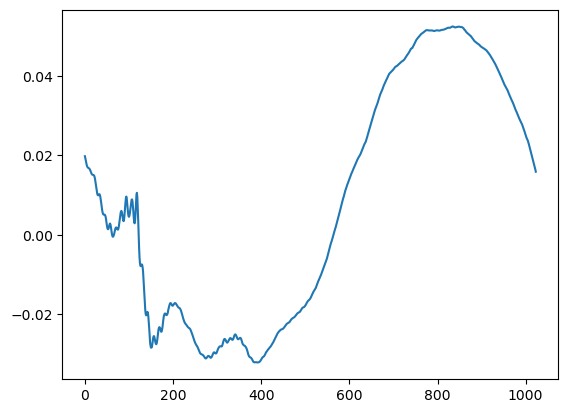

In [18]:
rt.all_plots(rt.error_nc)
plt.plot(rt.w)

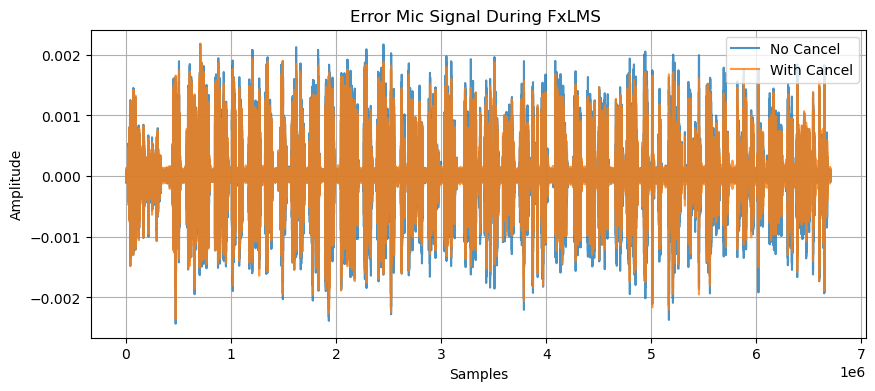

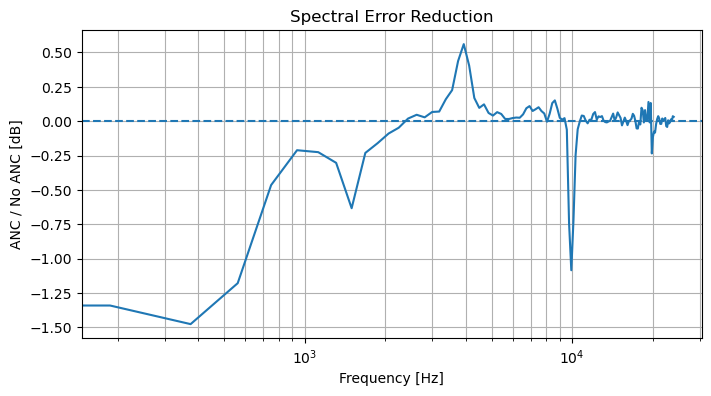

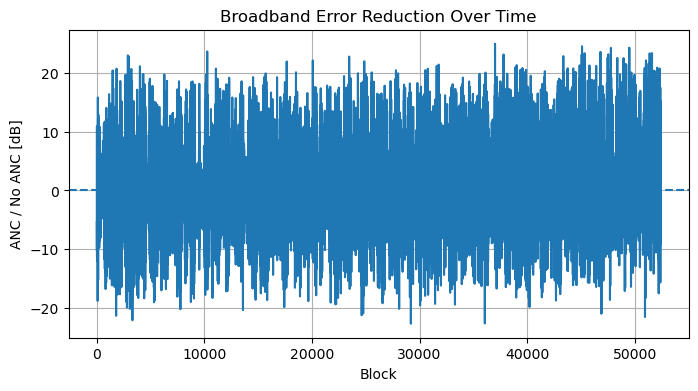

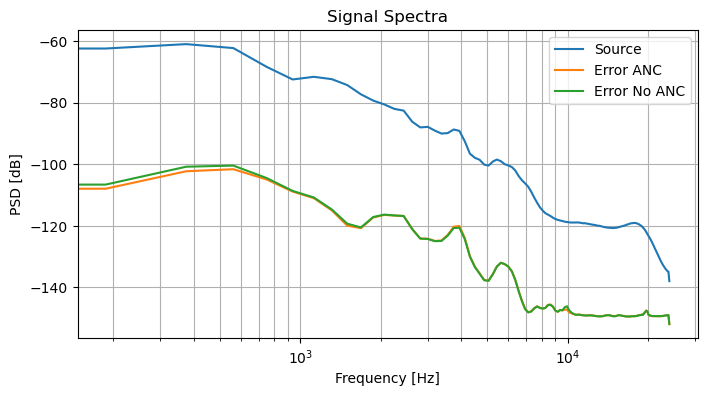

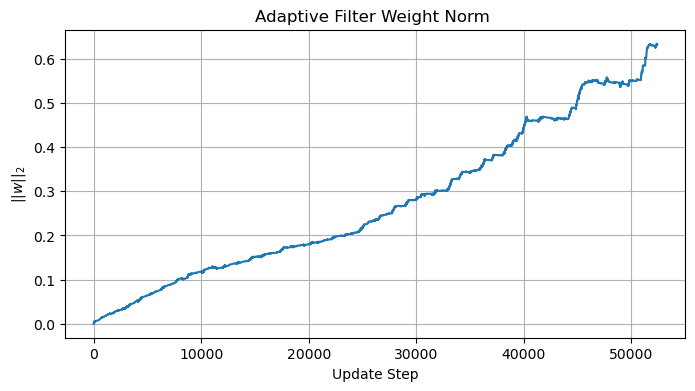

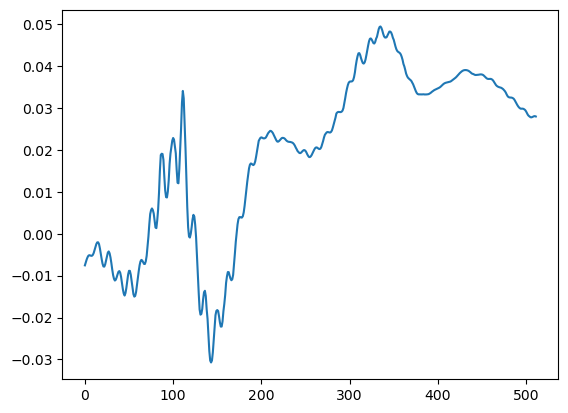

In [21]:
rt.reset(rt.system_lag, block_size=128, filter_order=512)
# rt.w[104] = 1.0

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=.2,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=5e-5,
    leak=1e-7,
    max_norm=1.0,
)

rt.all_plots(rt.error_nc)
plt.plot(rt.w)